In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car data.csv
/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car details v4.csv
/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/CAR DETAILS FROM CAR DEKHO.csv
/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/Car details v3.csv


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
data = pd.read_csv('/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/Car details v3.csv')
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [45]:
data.shape

(8128, 13)

In [46]:
data.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [47]:
data.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [48]:
data.duplicated().sum()

np.int64(1202)

In [49]:
data.drop_duplicates(inplace=True)
data.shape

(6926, 13)

In [50]:
data['mileage'].unique()[:10]

array(['23.4 kmpl', '21.14 kmpl', '17.7 kmpl', '23.0 kmpl', '16.1 kmpl',
       '20.14 kmpl', '17.3 km/kg', '23.59 kmpl', '20.0 kmpl',
       '19.01 kmpl'], dtype=object)

In [51]:
data['mileage'] = data['mileage'].str.split().str[0].astype(float)
data['mileage'].head()

0    23.40
1    21.14
2    17.70
3    23.00
4    16.10
Name: mileage, dtype: float64

In [52]:
data['engine'].unique()[:10]

array(['1248 CC', '1498 CC', '1497 CC', '1396 CC', '1298 CC', '1197 CC',
       '1061 CC', '796 CC', '1364 CC', '1399 CC'], dtype=object)

In [53]:
data['engine'] = data['engine'].str.replace(' CC', '').astype(float)
data['engine'].head()

0    1248.0
1    1498.0
2    1497.0
3    1396.0
4    1298.0
Name: engine, dtype: float64

In [54]:
data['max_power'].unique()[:10]

array(['74 bhp', '103.52 bhp', '78 bhp', '90 bhp', '88.2 bhp',
       '81.86 bhp', '57.5 bhp', '37 bhp', '67.1 bhp', '68.1 bhp'],
      dtype=object)

In [55]:
data['max_power'] = data['max_power'].str.replace(' bhp', '')
data['max_power'] = pd.to_numeric(data['max_power'], errors='coerce')
data['max_power'].head()

0     74.00
1    103.52
2     78.00
3     90.00
4     88.20
Name: max_power, dtype: float64

In [56]:
data['torque'].unique()[:15]

array(['190Nm@ 2000rpm', '250Nm@ 1500-2500rpm', '12.7@ 2,700(kgm@ rpm)',
       '22.4 kgm at 1750-2750rpm', '11.5@ 4,500(kgm@ rpm)',
       '113.75nm@ 4000rpm', '7.8@ 4,500(kgm@ rpm)', '59Nm@ 2500rpm',
       '170Nm@ 1800-2400rpm', '160Nm@ 2000rpm', '248Nm@ 2250rpm',
       '78Nm@ 4500rpm', nan, '84Nm@ 3500rpm', '115Nm@ 3500-3600rpm'],
      dtype=object)

In [57]:
torque_value = data['torque'].str.extract(r'([\d\.]+)')[0].astype(float)
is_kgm = data['torque'].str.contains('kgm', case=False, na=False)
torque_value[is_kgm] = torque_value[is_kgm] * 9.80665

data['torque'] = torque_value
data['torque'].head(10)

0    190.000000
1    250.000000
2    124.544455
3    219.668960
4    112.776475
5    113.750000
6     76.491870
7     59.000000
8    170.000000
9    160.000000
Name: torque, dtype: float64

In [58]:
data.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          208
engine           208
max_power        206
torque           209
seats            208
dtype: int64

In [59]:
data.dropna(inplace=True)
data.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64

In [60]:
data.shape

(6717, 13)

In [61]:
data['name'].unique()[:10]

array(['Maruti Swift Dzire VDI', 'Skoda Rapid 1.5 TDI Ambition',
       'Honda City 2017-2020 EXi', 'Hyundai i20 Sportz Diesel',
       'Maruti Swift VXI BSIII', 'Hyundai Xcent 1.2 VTVT E Plus',
       'Maruti Wagon R LXI DUO BSIII', 'Maruti 800 DX BSII',
       'Toyota Etios VXD', 'Ford Figo Diesel Celebration Edition'],
      dtype=object)

In [62]:
data['brand'] = data['name'].str.split().str[0]
data.drop('name', axis=1, inplace=True)
data.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,brand
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190.000000,5.0,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250.000000,5.0,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,124.544455,5.0,Honda
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,219.668960,5.0,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,112.776475,5.0,Maruti


In [63]:
data['brand'].unique()

array(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Datsun', 'Jeep', 'Mercedes-Benz',
       'Mitsubishi', 'Audi', 'Volkswagen', 'BMW', 'Nissan', 'Lexus',
       'Jaguar', 'Land', 'MG', 'Volvo', 'Daewoo', 'Kia', 'Fiat', 'Force',
       'Ambassador', 'Ashok', 'Isuzu', 'Opel'], dtype=object)

In [64]:
numerical_cols = data.select_dtypes('number').columns.tolist()

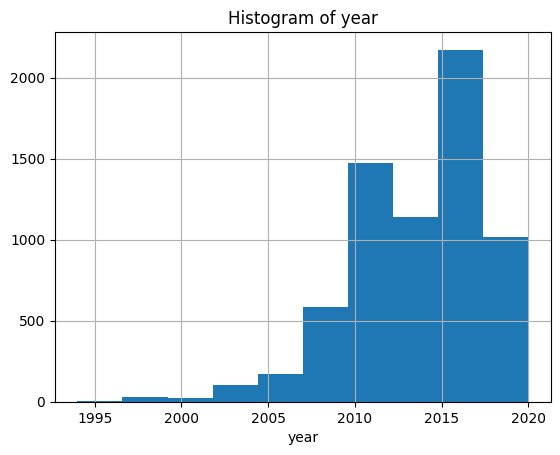

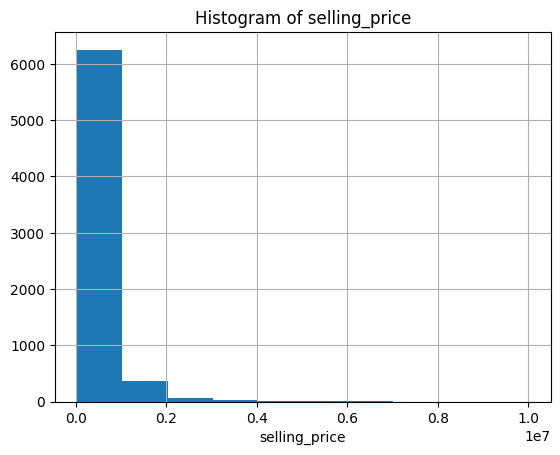

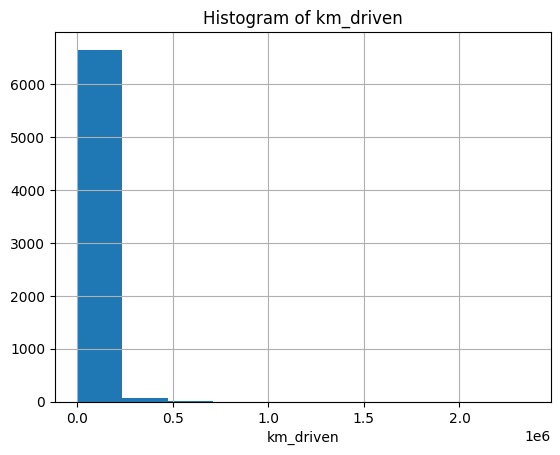

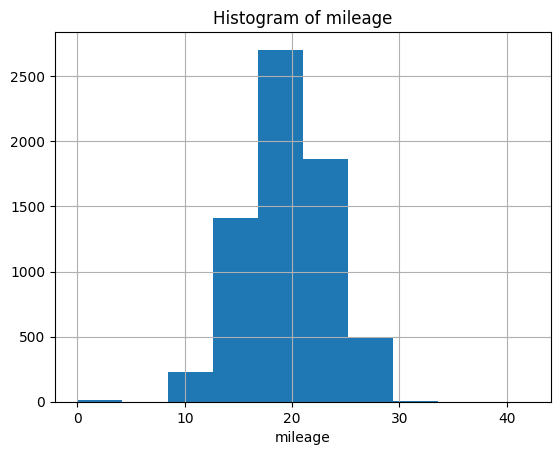

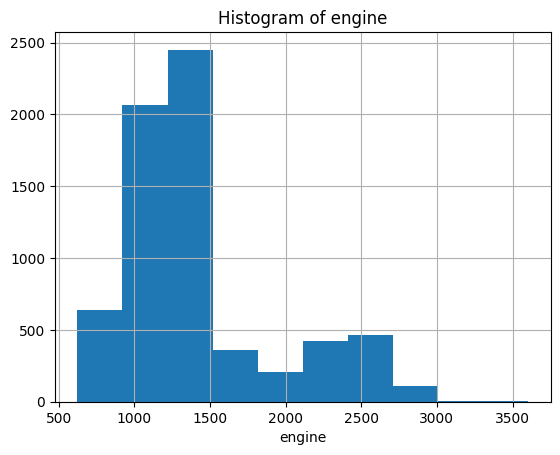

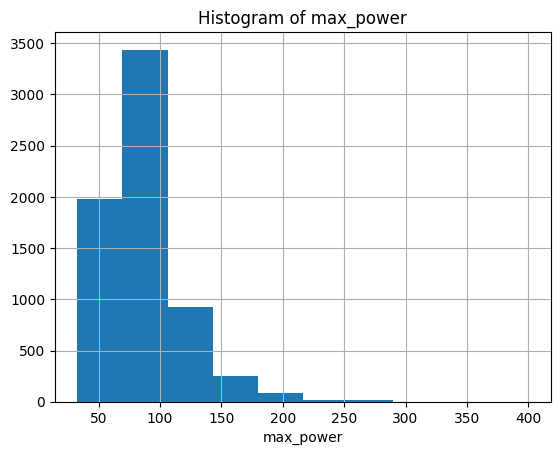

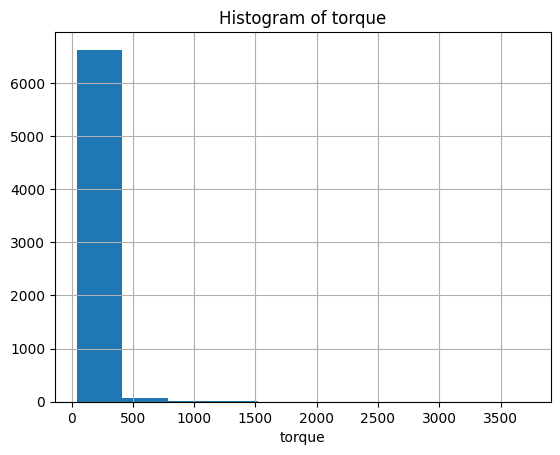

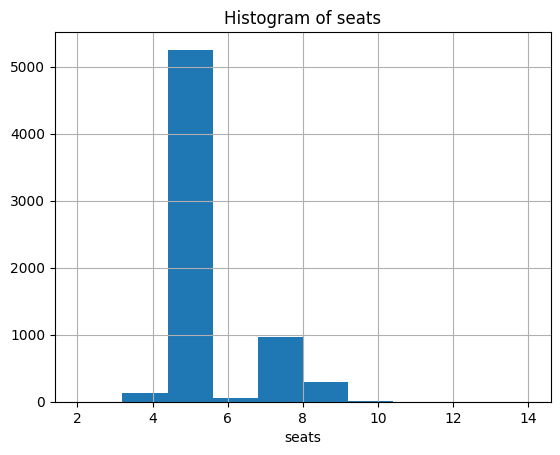

In [65]:
for col in numerical_cols:
    plt.figure()
    data[col].hist()
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.show()

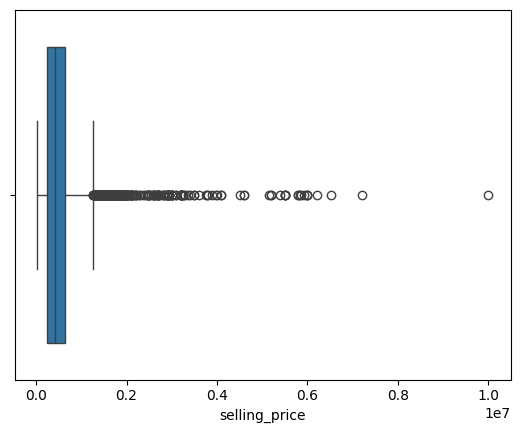

In [66]:
sns.boxplot(x=data['selling_price'])
plt.show()

In [67]:
data['selling_price'].max()

10000000

# since its logically posible for a huge variance in prices to exist, therefore we wont remove outlays

In [68]:
data['fuel'].value_counts()

fuel
Diesel    3658
Petrol    2973
CNG         51
LPG         35
Name: count, dtype: int64

In [69]:
data['seller_type'].value_counts()

seller_type
Individual          6024
Dealer               666
Trustmark Dealer      27
Name: count, dtype: int64

In [70]:
data['transmission'].value_counts()

transmission
Manual       6142
Automatic     575
Name: count, dtype: int64

In [71]:
data['owner'].value_counts()

owner
First Owner             4176
Second Owner            1888
Third Owner              493
Fourth & Above Owner     155
Test Drive Car             5
Name: count, dtype: int64

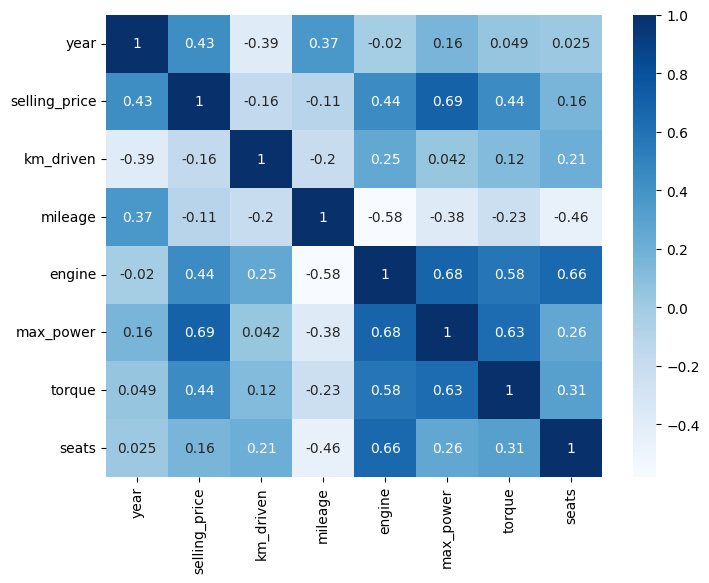

In [72]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='Blues')
plt.show()

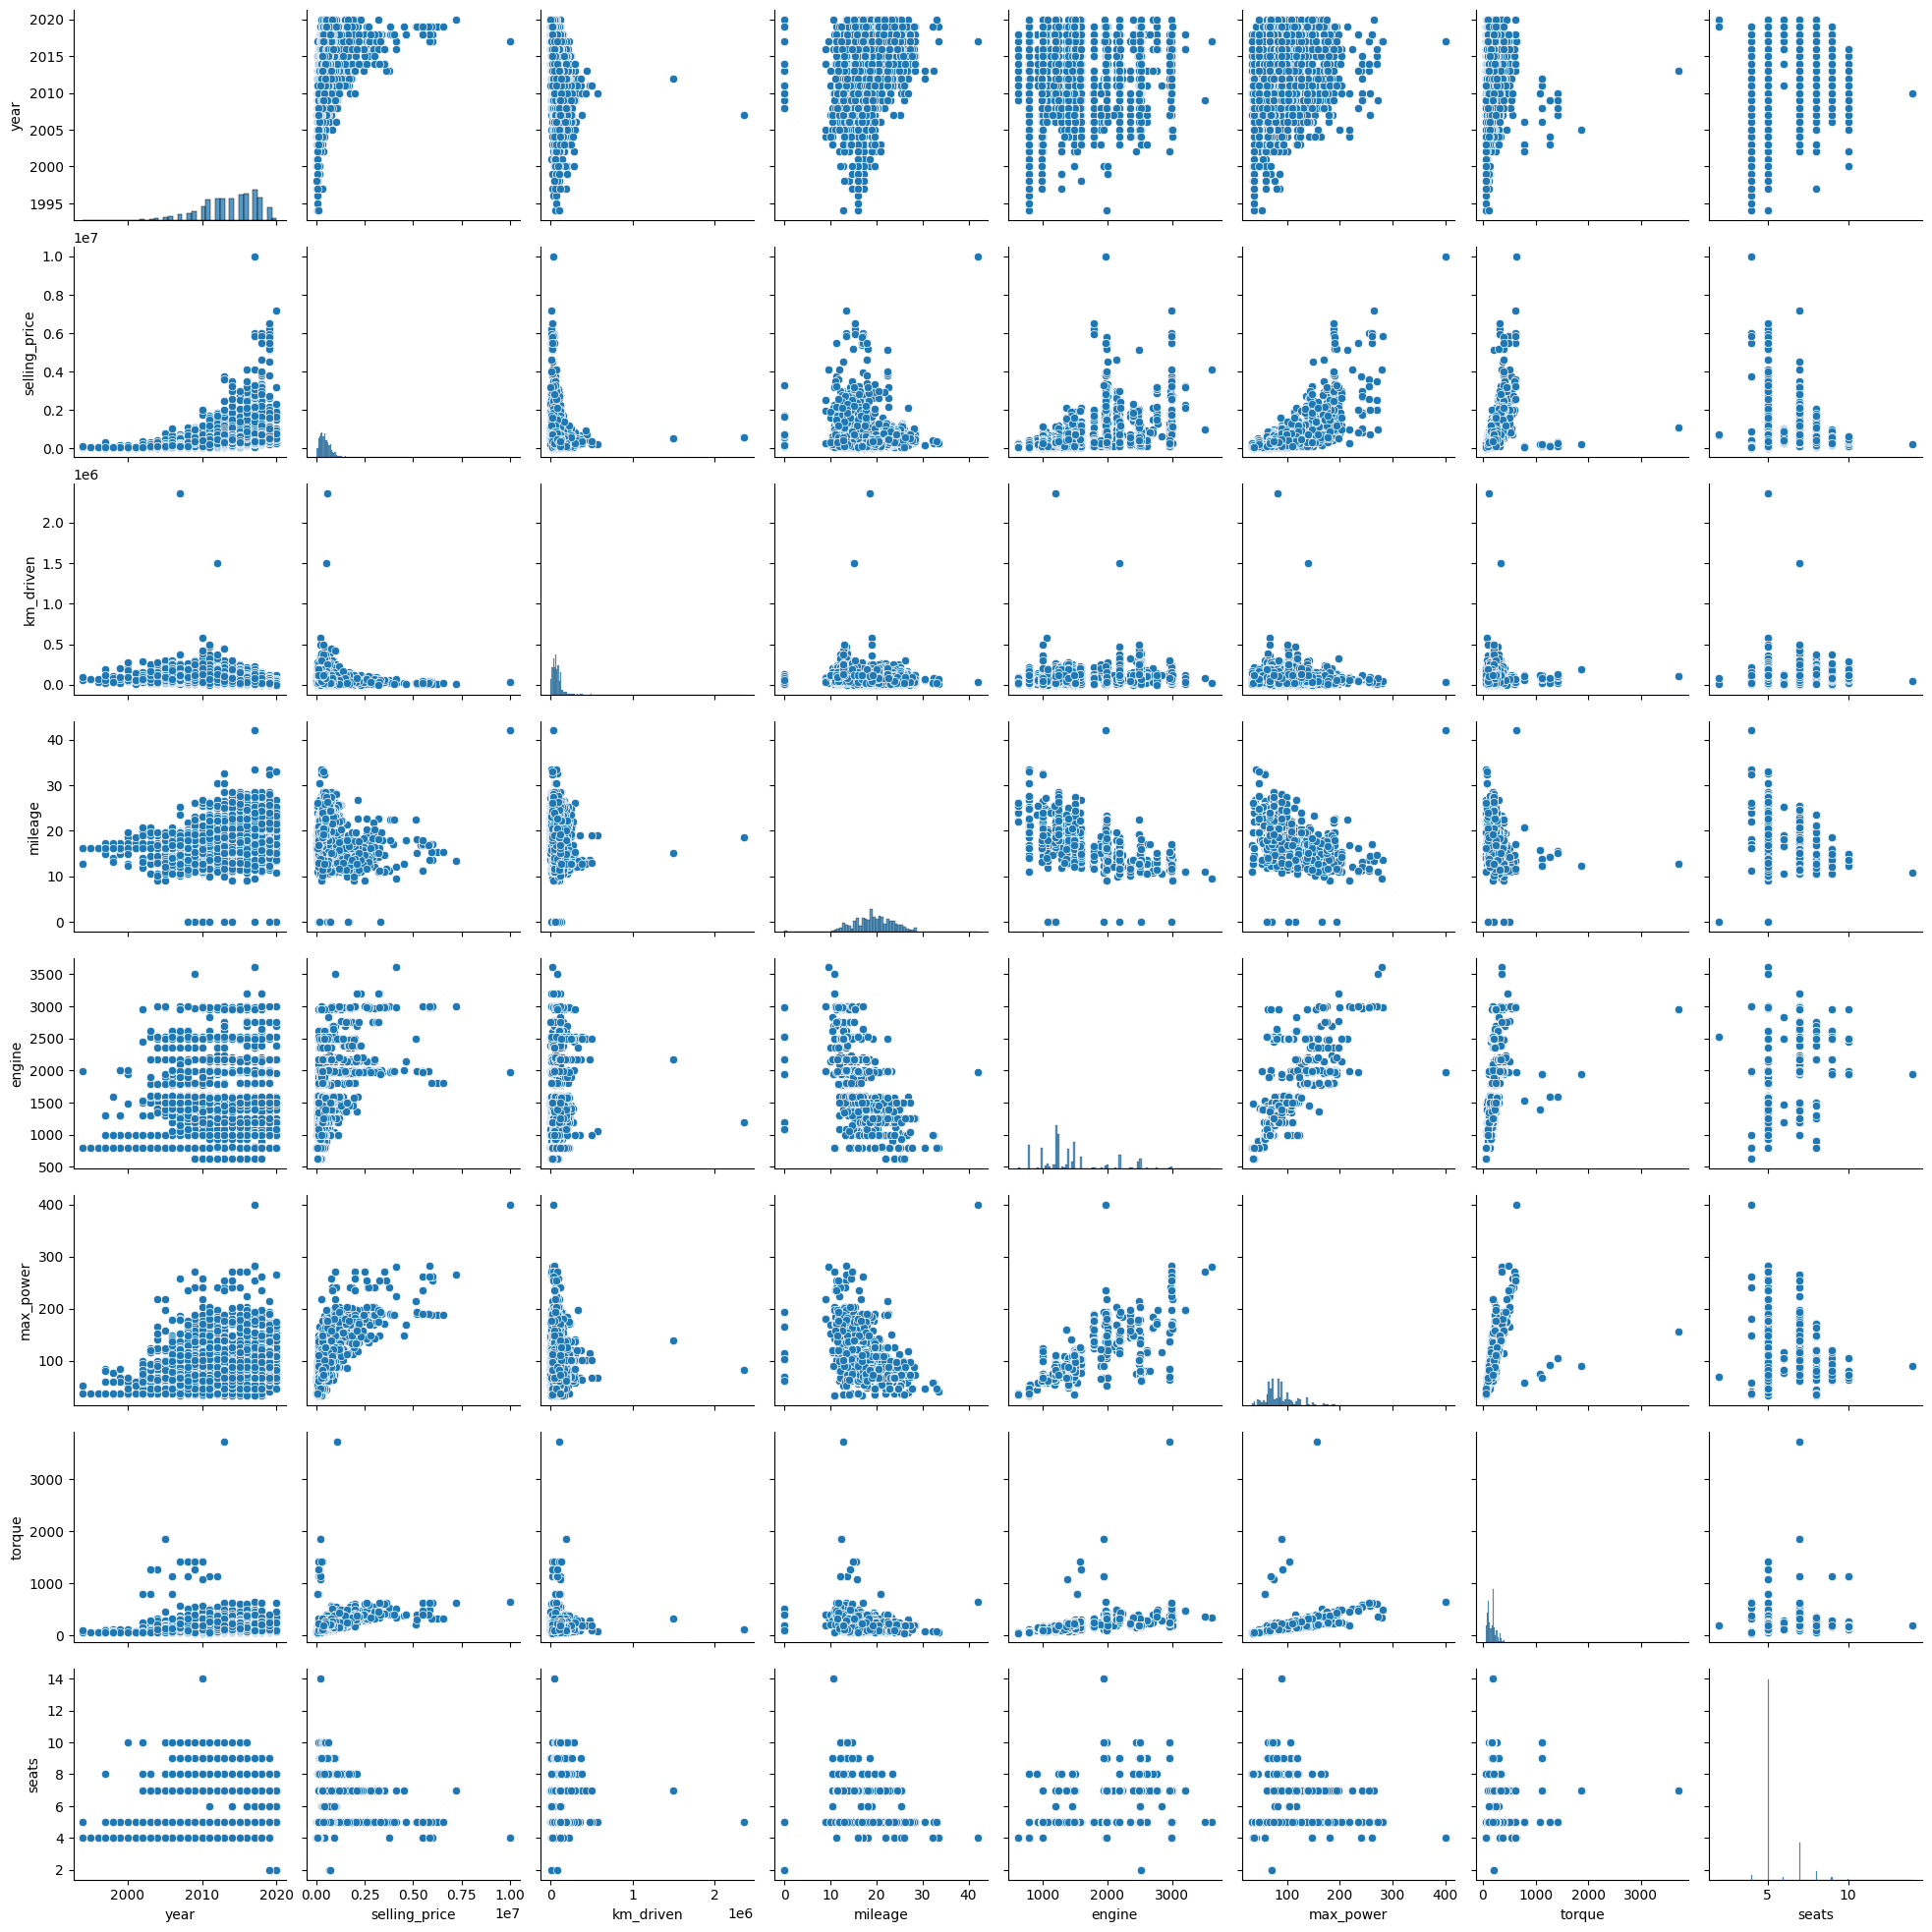

In [73]:
sns.pairplot(data[numerical_cols])
plt.show()

In [74]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

In [75]:
data.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,brand
0,2014,450000,145500,1,1,1,0,23.40,1248.0,74.00,190.000000,5.0,20
1,2014,370000,120000,1,1,1,2,21.14,1498.0,103.52,250.000000,5.0,26
2,2006,158000,140000,3,1,1,4,17.70,1497.0,78.00,124.544455,5.0,10
3,2010,225000,127000,1,1,1,0,23.00,1396.0,90.00,219.668960,5.0,11
4,2007,130000,120000,3,1,1,0,16.10,1298.0,88.20,112.776475,5.0,20


In [76]:
from sklearn.preprocessing import StandardScaler

X = data.drop('selling_price', axis=1)
y = data['selling_price']

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [78]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [79]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [80]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

print("Linear Regression")
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Linear Regression
Train R²: 0.6124081241044192
Test R²: 0.6606044503017415
MAE: 168385.2233461429
RMSE: 272898.93446954334


In [81]:
svr = SVR()

svr.fit(X_train, y_train)

y_train_pred = svr.predict(X_train)
y_test_pred = svr.predict(X_test)

print("\nSVR")
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))


SVR
Train R²: -0.038489737434178384
Test R²: -0.032057186410109795
MAE: 270595.6086650337
RMSE: 475883.5026073704


In [82]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

print("\nDecision Tree")
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))


Decision Tree
Train R²: 0.9991498633959339
Test R²: 0.8420046588457624
MAE: 97633.77938988095
RMSE: 186196.2408980587


In [83]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

print("\nRandom Forest")
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))


Random Forest
Train R²: 0.9858148375863491
Test R²: 0.9292812761978131
MAE: 73373.16459184559
RMSE: 124570.72030343565


In [84]:
ada = AdaBoostRegressor(
    random_state=42,
    n_estimators=100
)

ada.fit(X_train, y_train)

y_train_pred = ada.predict(X_train)
y_test_pred = ada.predict(X_test)

print("\nAdaBoost")
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))


AdaBoost
Train R²: 0.48020904924168206
Test R²: 0.3089744186771298
MAE: 346751.51183259196
RMSE: 389399.8956312443
